# II. Machine Learning development

In this notebook:
 1. ML model training
 2. SHAP-analysis
 3. Model-based optimization

In [1]:
# Import of libraries:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root / "scripts"))

from typing import Any, Dict

import random
import pandas as pd
import numpy as np
from my_scripts import *
import os

import matplotlib.pyplot as plt
import matplotlib.text as mtext

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, TweedieRegressor, ElasticNet
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb

In [2]:
# Disable warring for GPR and XGBoost hyperparameters optimization and old API warring
import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [3]:
# Paths
path_to_data = '../data'
path_to_image = '../images'
path_to_models = '../models'
path_to_tables = '../tables'

In [4]:
# Fixing of all seeds
seed = 7
np.random.seed(seed)
random.seed(seed)

In [5]:
# Load the prepared dataset
df = pd.read_csv(os.path.join(path_to_data,'task.csv'), index_col=0)

In [6]:
# Splittig on train and test subset with stratification by anion composition
counts = df['Composition'].value_counts()
rare = counts[counts < 3].index

df_rare = df[df['Composition'].isin(rare)]
df_common = df[~df['Composition'].isin(rare)]

X_common = df_common.drop(columns=['Refcode', 'Bandgap', 'Composition'])
y_common = df_common['Bandgap']

X_train_c, X_test, y_train_c, y_test = train_test_split(X_common, y_common,
                                                        test_size=0.15,
                                                        stratify=df_common['Composition'],
                                                        random_state=seed)

X_train = pd.concat([X_train_c, df_rare.drop(columns=['Refcode', 'Bandgap', 'Composition'])])
y_train = pd.concat([y_train_c, df_rare['Bandgap']])

In [7]:
# Check for data leakage absence
assert len(set(X_train.index) & set(X_test.index)) == 0

In [8]:
# Descriptor groups:
distance_angle_names = ['X_t1', 'X_t2', 'X_d1', 'X_d2', 'X_d3', 'X_d4', 't1_t2', 't1_d1', 't1_d2', 't1_d3', 't1_d4', 't2_d1', 't2_d2', 't2_d3', 't2_d4', 'd1_d2', 'd1_d3', 'd1_d4', 'd2_d3', 'd2_d4', 'd3_d4']
distortion_names = ['d_average', 'delta_d', 'sigma_2']
nci_names = ['N_XX', 'N_VdW', 'XXmin_2r', 'XXaver_2r', 'VdW_2r']
composition_names = ['M', 'I', 'Br', 'Cl']

# Split train subset on two descriptor grous
X_train1 = X_train[['Temperature']+distance_angle_names+nci_names+composition_names].copy()
X_train2 = X_train[['Temperature']+distortion_names+nci_names+composition_names].copy()

In [9]:
# Set correlation coefficient treshold
correlation_treshold = 0.9

In [10]:
# Choising models
models_dict: Dict[str, Any] = {'Linear': LinearRegression,
                               'GLR': TweedieRegressor,
                               'ElasticNet': ElasticNet,
                               'SVR': SVR,
                               'GPR': GaussianProcessRegressor,
                               'RandomForest': RandomForestRegressor,
                               'ExtraTrees': ExtraTreesRegressor,
                               'XGBoost': xgb.XGBRegressor,
                               }

In [11]:
# Descriptor value ranges for model-based optimization
descriptor_bounds = {'Temperature': (290., 300.),
                      'X_t1': (2.5, 3.4),
                      'X_t2': (2.5, 3.4),
                      'X_d1': (2.5, 3.4),
                      'X_d2': (2.5, 3.4),
                      'X_d3': (2.5, 3.4),
                      'X_d4': (2.5, 3.4),
                      't1_t2': (75, 105), 
                      't1_d1': (75, 105),
                      't1_d2': (75, 105), 
                      't1_d3': (148.0, 180.),
                      't1_d4': (75, 105), 
                      't2_d1': (163.0, 180.),
                      't2_d2': (75, 105),
                      't2_d3': (75, 105), 
                      't2_d4': (75, 105),
                      'd1_d2': (75, 105),
                      'd1_d3': (75, 105),
                      'd1_d4': (75, 105),
                      'd2_d3': (75, 105),
                      'd2_d4': (168.0, 180.),
                      'd3_d4': (75, 105),
                      'd_average': (2.5, 3.15),
                      'delta_d': (0., 0.002),
                      'sigma_2': (0., 23.),
                      'N_XX': (0.5, 16),
                      'N_VdW': (0, 16),
                      'XXmin_2r': (0.7, 1.1),
                      'XXaver_2r': (0.7, 1.1),
                      'VdW_2r': (0.7, 1.1),
                      'M': (0, 0),
                      'I': (1, 1),
                      'Br': (0, 0),
                      'Cl': (0, 0)
                      }

# Find objects with minimal band gap value for model-based optimization start
min_band_gap_values_inxs = y_train.sort_values().index[:2]

***

## 1. Full Geometrical Descriptor Space

In [12]:
# Find correlated descriptors
corr_map_1 = build_corr_map(X_train1)

corr_filter_1 = corr_map_1.loc[(corr_map_1.abs() >= correlation_treshold).any(axis=1), (corr_map_1.abs() >= correlation_treshold).any(axis=0)]
to_drop_1 = corr_filter_1[corr_filter_1.abs()>correlation_treshold].index
corr_filter_1[corr_filter_1.abs()>correlation_treshold]


,X_t1,X_t2,XXmin_2r
X_t2,0.979507,NaN,NaN
X_d4,0.928549,0.918749,NaN
VdW_2r,NaN,NaN,0.986533
I,0.919094,0.913951,NaN


In [13]:
# Deleting correlated descriptors
X_train1.drop(columns=to_drop_1, inplace=True)

In [14]:
# Visualization of correlation map of final features
corr_map_1_1 = build_corr_map(X_train1)

fig_1 = heatmap_plot(corr_map=corr_map_1_1, layout_params=dict(title=dict(text="Descriptor Heatmap on train subset for FGDS", y=.985), margin=dict(t=150)))
fig_1.show()

In [15]:
# Variance Inflation Factor (VIF) analysis to remove linear dependant geometric descriptors
X = X_train1[filter(lambda x: x in distance_angle_names, X_train1.columns)].copy()
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)for i in range(X.shape[1])]
X_train1.drop(columns=vif.sort_values('VIF').iloc[12:, 0].values, inplace=True)

In [16]:
# Mutual Information (MI) test for noised NCI descriptors detection
mi1 = mutual_info_regression(X_train1[filter(lambda x: x in nci_names, X_train1.columns)], y_train, random_state=7)
mi1 = pd.Series(mi1, index=filter(lambda x: x in nci_names, X_train1.columns), name='MI').sort_values(ascending=False)
mi1

N_VdW        0.448298
XXmin_2r     0.445168
XXaver_2r    0.295234
N_XX         0.105530
Name: MI, dtype: float64

In [17]:
# Check the absence of noised NCI descriptors
assert all(mi1 > 0.05)

In [18]:
# Hyperparameter optimization
best_trials1 = hyperparameter_optimization(models_dict=models_dict, X_train=X_train1, y_train=y_train, seed=seed, n_trials=250)

[I 2026-02-25 19:48:34,277] A new study created in memory with name: no-name-5dfc5d54-8ebe-4769-9238-49e4789bcd8d
[I 2026-02-25 19:48:34,479] Trial 0 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value: 0.11464220906242392.


Optimizing Linear...


[I 2026-02-25 19:48:34,656] Trial 1 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value: 0.11464220906242392.
[I 2026-02-25 19:48:34,833] Trial 2 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value: 0.11464220906242392.
[I 2026-02-25 19:48:35,009] Trial 3 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value: 0.11464220906242392.
[I 2026-02-25 19:48:35,184] Trial 4 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value: 0.11464220906242392.
[I 2026-02-25 19:48:35,371] Trial 5 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value: 0.11464220906242392.
[I 2026-02-25 19:48:35,592] Trial 6 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value: 0.11464220906242392.
[I 2026-02-25 19:48:35,819] Trial 7 finished with value: 0.11464220906242392 and parameters: {}. Best is trial 0 with value:

Best params for Linear: {}, Score: 0.1146

Optimizing GLR...


[I 2026-02-25 19:49:20,259] Trial 0 finished with value: 0.11939591689933239 and parameters: {'power': 0.15261657874791434, 'alpha': 0.2880259022108665}. Best is trial 0 with value: 0.11939591689933239.
[I 2026-02-25 19:49:21,042] Trial 1 finished with value: 0.11917575850749186 and parameters: {'power': 0.876818462881787, 'alpha': 0.11594612660804}. Best is trial 1 with value: 0.11917575850749186.
[I 2026-02-25 19:49:21,896] Trial 2 finished with value: 0.11727753466097175 and parameters: {'power': 1.9559790239932053, 'alpha': 0.005881269664508251}. Best is trial 2 with value: 0.11727753466097175.
[I 2026-02-25 19:49:23,013] Trial 3 finished with value: 0.11725046662319032 and parameters: {'power': 1.0022409273198758, 'alpha': 3.1941693167021597e-06}. Best is trial 3 with value: 0.11725046662319032.
[I 2026-02-25 19:49:24,276] Trial 4 finished with value: 0.11548991313945557 and parameters: {'power': 0.5368779602037423, 'alpha': 0.003156294407244228}. Best is trial 4 with value: 0.115

...

Best params for RandomForest: {'n_estimators': 219, 'max_depth': 13}, Score: 0.1040

Optimizing ExtraTrees...


[I 2026-02-25 21:03:24,340] Trial 0 finished with value: 0.10829107100819613 and parameters: {'n_estimators': 69, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.9889947559983013}. Best is trial 0 with value: 0.10829107100819613.
[I 2026-02-25 21:03:30,680] Trial 1 finished with value: 0.1065952314257598 and parameters: {'n_estimators': 185, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.74994125041278}. Best is trial 1 with value: 0.1065952314257598.
[I 2026-02-25 21:03:38,900] Trial 2 finished with value: 0.10519303528939178 and parameters: {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.6440727996539968}. Best is trial 2 with value: 0.10519303528939178.
[I 2026-02-25 21:03:48,379] Trial 3 finished with value: 0.12243718807363928 and parameters: {'n_estimators': 278, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 0.512449613775174}.

Best params for ExtraTrees: {'n_estimators': 107, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.589745921344805}, Score: 0.1012

Optimizing XGBoost...


[I 2026-02-25 21:27:04,586] Trial 0 finished with value: 0.1490280658963739 and parameters: {'max_depth': 2, 'learning_rate': 0.2113774399969529, 'subsample': 0.6753636925763574, 'colsample_bytree': 0.7893860711323765, 'min_child_weight': 10}. Best is trial 0 with value: 0.1490280658963739.
[I 2026-02-25 21:27:11,011] Trial 1 finished with value: 0.16332327347599 and parameters: {'max_depth': 4, 'learning_rate': 0.07102130307325003, 'subsample': 0.5288204533439046, 'colsample_bytree': 0.6073755920407484, 'min_child_weight': 6}. Best is trial 0 with value: 0.1490280658963739.
[I 2026-02-25 21:27:16,359] Trial 2 finished with value: 0.1454231837771363 and parameters: {'max_depth': 4, 'learning_rate': 0.2320216514657092, 'subsample': 0.6523764532594154, 'colsample_bytree': 0.5263745387623621, 'min_child_weight': 5}. Best is trial 2 with value: 0.1454231837771363.
[I 2026-02-25 21:27:24,218] Trial 3 finished with value: 0.22340090265687507 and parameters: {'max_depth': 5, 'learning_rate': 

Best params for XGBoost: {'max_depth': 2, 'learning_rate': 0.2019735230593428, 'subsample': 0.8082988482679815, 'colsample_bytree': 0.8990226902149916, 'min_child_weight': 3}, Score: 0.1166



In [19]:
# Train and validate final models
final_pipelines1, predicted_values1, results1 = train_and_validate(hyperparameters_dict=best_trials1, X_train=X_train1, y_train=y_train, seed=seed)

LOO-CV for Linear
RMSE on LOO-CV: 0.1146

Train final Linear

LOO-CV for GLR
RMSE on LOO-CV: 0.1142

Train final GLR

LOO-CV for ElasticNet
RMSE on LOO-CV: 0.1085

Train final ElasticNet

LOO-CV for SVR
RMSE on LOO-CV: 0.1125

Train final SVR

LOO-CV for GPR
RMSE on LOO-CV: 0.113

Train final GPR

LOO-CV for RandomForest
RMSE on LOO-CV: 0.104

Train final RandomForest

LOO-CV for ExtraTrees
RMSE on LOO-CV: 0.1012

Train final ExtraTrees

LOO-CV for XGBoost
RMSE on LOO-CV: 0.1166

Train final XGBoost



In [20]:
# Predict on test
predicted_values1, results1 = predict_models(final_pipelines=final_pipelines1, predicted_values=predicted_values1, results=results1, X_train=X_train1, X_test=X_test, y_test=y_test)

RMSE on test for Linear: 0.1204

RMSE on test for GLR: 0.1188

RMSE on test for ElasticNet: 0.1187

RMSE on test for SVR: 0.1175

RMSE on test for GPR: 0.1198

RMSE on test for RandomForest: 0.0669

RMSE on test for ExtraTrees: 0.0658

RMSE on test for XGBoost: 0.1045



In [21]:
# Result tables
results_df1 = pd.DataFrame(results1).T.sort_values('RMSE on test')
best_model_name1 = results_df1.index[0]
results_df1

,MAE on train,RMSE on train,R2 on train,MAE on validation,RMSE on validation,R2 on validation,MAE on test,RMSE on test,R2 on test
ExtraTrees,0.025292,0.036329,0.994232,0.070829,0.101220,0.955220,0.047605,0.065832,0.978426
RandomForest,0.028958,0.038686,0.993459,0.079362,0.104022,0.952706,0.055093,0.066948,0.977689
XGBoost,0.053695,0.076672,0.974306,0.086061,0.116590,0.940588,0.091660,0.104538,0.945600
SVR,0.062546,0.090717,0.964031,0.085643,0.112488,0.944695,0.082201,0.117527,0.931243
ElasticNet,0.071656,0.092052,0.962965,0.083867,0.108455,0.948590,0.087772,0.118695,0.929869
GLR,0.067244,0.086616,0.967210,0.088076,0.114199,0.942999,0.085346,0.118774,0.929776
GPR,0.067396,0.087409,0.966606,0.086885,0.112982,0.944208,0.083923,0.119786,0.928574
Linear,0.067641,0.086991,0.966925,0.089212,0.114642,0.942556,0.083941,0.120367,0.927879


In [22]:
# Predicted vs Actual plot for best model
print(f'Best model – {best_model_name1}:')
fig_2 = single_predicted_vs_actual_plot(y_train_pred=predicted_values1['train'][best_model_name1], y_train_true=y_train,
                                        y_test_pred=predicted_values1['test'][best_model_name1], y_test_true=y_test,
                                        train_text=df.loc[y_train.index, 'Refcode'], test_text=df.loc[y_test.index, 'Refcode'],
                                        layout_params=dict(legend=dict(x=.85, y=.025)))
fig_2.add_annotation(text=f"On test:<br>MAE = {round(results_df1.loc[best_model_name1, 'MAE on test'], 2):.2f}<br>RMSE = {round(results_df1.loc[best_model_name1, 'RMSE on test'], 2):.2f}<br>R<sup>2</sup> = {round(results_df1.loc[best_model_name1, 'R2 on test'], 4):.4f}",
                     x=1.9, y=3.25, font=dict(size=32), align='left')
fig_2.show()

Best model – ExtraTrees:


In [23]:
# Predicted vs Actual plots for all models
fig_3 = predicted_vs_actual_plots(predicted_values=predicted_values1, results_df=results_df1, y_train_true=y_train, y_test_true=y_test, train_text=df.loc[y_train.index, 'Refcode'], test_text=df.loc[y_test.index, 'Refcode'])
fig_3.show()

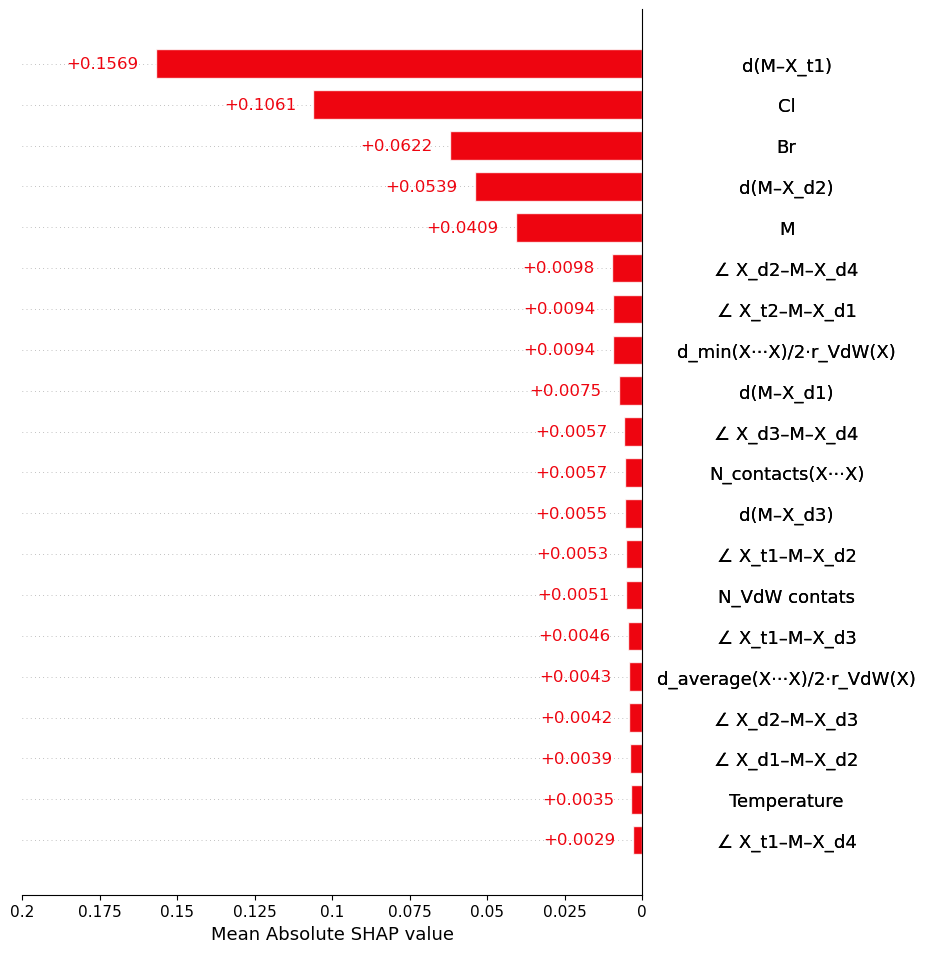

In [58]:
# Compute and visualization SHAP explanation
shap_vals1 = shap_explation(final_pipelines1, best_model_name1, X_train1)
shap_bar_plot(shap_values=shap_vals1, xlim_max=19, text_shift=2.7, change_colors=True)
plt.savefig(os.path.join(path_to_image, 'shap_bar_fgds.png'), dpi=720, bbox_inches='tight')

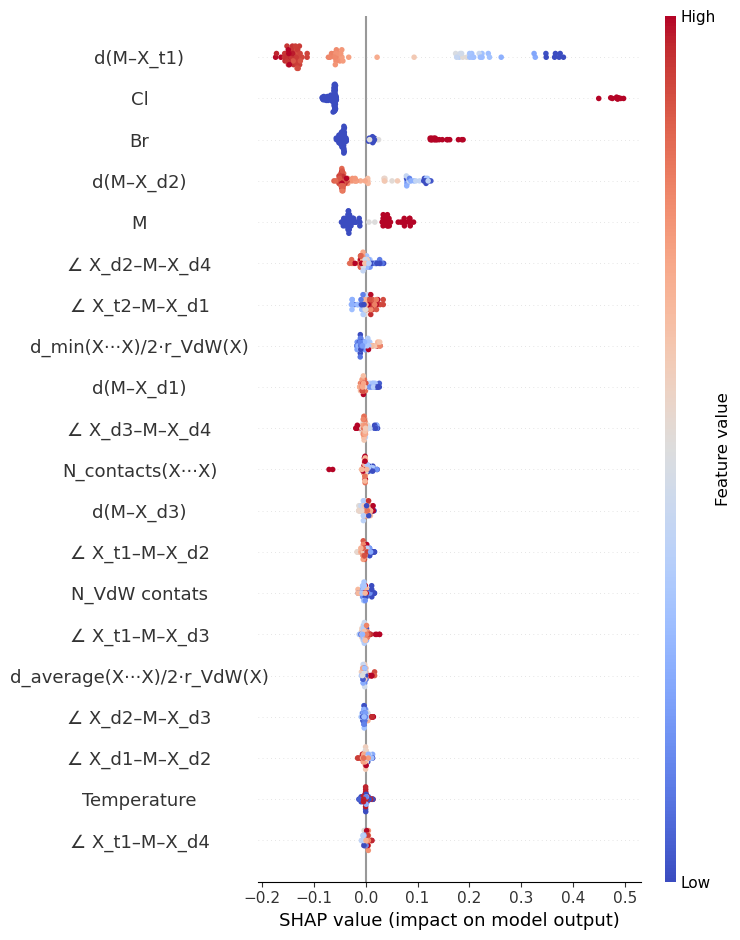

In [25]:
# Visualization SHAP explanations as beeswarm plot
shap.summary_plot(shap_vals1, X_train1, show=False, cmap = 'coolwarm', max_display=25)

# Make centering of Y axis labels
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.225)

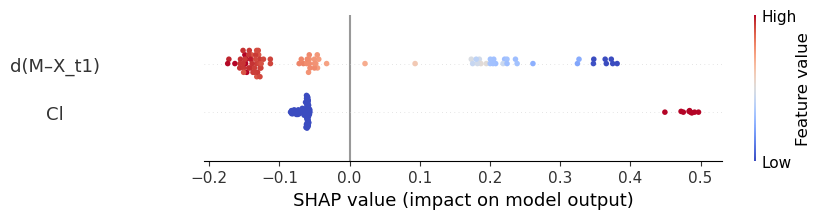

In [26]:
# For publication
shap.summary_plot(shap_vals1, X_train1, show=False, cmap = 'coolwarm', max_display=2)

# Make centering of Y axis labels
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.225)

plt.savefig(os.path.join(path_to_image, 'shap_beeswarm_fgds_1.png'), dpi=720, bbox_inches='tight')

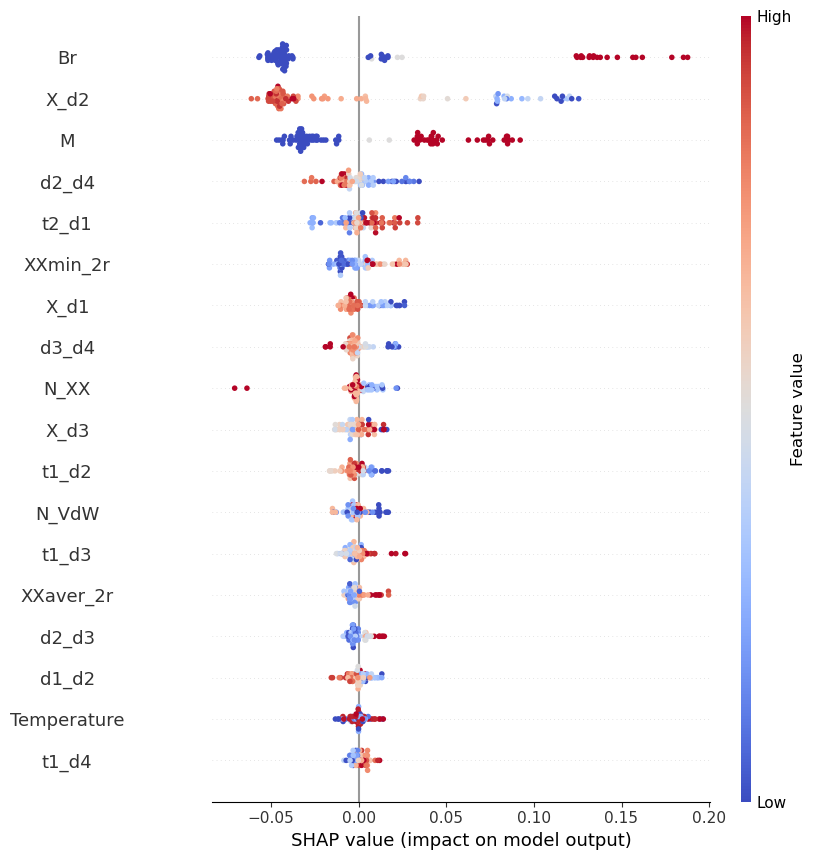

In [27]:
less_important_cols_ind = [x for x in range(X_train1.shape[1]) if x not in pd.Series(np.abs(shap_vals1.values).mean(0)).sort_values()[-2:].index.to_list()]
shap.summary_plot(shap_vals1.values[:, less_important_cols_ind ], X_train1.iloc[:,less_important_cols_ind], show=False, cmap = 'coolwarm')

# Make centering of Y axis labels
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.225)

plt.savefig(os.path.join(path_to_image, 'shap_beeswarm_fgds_2.png'), dpi=720, bbox_inches='tight')

***

## 2. Reduced Distortion Descriptor Space

In [28]:
# Find correlated descriptors
corr_map_2 = build_corr_map(X_train2)

corr_filter_2 = corr_map_2.loc[(corr_map_2.abs() >= correlation_treshold).any(axis=1), (corr_map_2.abs() >= correlation_treshold).any(axis=0)]
to_drop_2 = corr_filter_2[corr_filter_2.abs()>correlation_treshold].index
corr_filter_2[corr_filter_2.abs()>correlation_treshold]

,d_average,XXmin_2r
VdW_2r,NaN,0.986533
I,0.933576,NaN


In [29]:
# Deleting correlated descriptors
X_train2.drop(columns=to_drop_2, inplace=True)

In [30]:
# Visualization of correlation map of final features
corr_map_2_1 = build_corr_map(X_train2)

fig_5 = heatmap_plot(corr_map=corr_map_2_1, layout_params=dict(title=dict(text="Descriptor Heatmap on train subset for RDDS", y=.975), margin=dict(t=200), width=1200, height=1200, font_size=14, xaxis=dict(tickangle=45)))
fig_5.show()

In [31]:
# Hyperparameter optimization
best_trials2 = hyperparameter_optimization(models_dict=models_dict, X_train=X_train2, y_train=y_train, seed=seed, n_trials=250)

[I 2026-02-25 21:46:19,241] A new study created in memory with name: no-name-105c8e39-10ea-4c01-84ca-d7757cbf1df2
[I 2026-02-25 21:46:19,367] Trial 0 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value: 0.11646310171808204.


Optimizing Linear...


[I 2026-02-25 21:46:19,493] Trial 1 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value: 0.11646310171808204.
[I 2026-02-25 21:46:19,616] Trial 2 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value: 0.11646310171808204.
[I 2026-02-25 21:46:19,739] Trial 3 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value: 0.11646310171808204.
[I 2026-02-25 21:46:19,862] Trial 4 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value: 0.11646310171808204.
[I 2026-02-25 21:46:19,985] Trial 5 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value: 0.11646310171808204.
[I 2026-02-25 21:46:20,109] Trial 6 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value: 0.11646310171808204.
[I 2026-02-25 21:46:20,232] Trial 7 finished with value: 0.11646310171808204 and parameters: {}. Best is trial 0 with value:

Best params for Linear: {}, Score: 0.1165

Optimizing GLR...


[I 2026-02-25 21:46:50,611] Trial 0 finished with value: 0.11827920795312427 and parameters: {'power': 0.15261657874791434, 'alpha': 0.2880259022108665}. Best is trial 0 with value: 0.11827920795312427.
[I 2026-02-25 21:46:51,251] Trial 1 finished with value: 0.1180127580009524 and parameters: {'power': 0.876818462881787, 'alpha': 0.11594612660804}. Best is trial 1 with value: 0.1180127580009524.
[I 2026-02-25 21:46:51,983] Trial 2 finished with value: 0.11900165778462328 and parameters: {'power': 1.9559790239932053, 'alpha': 0.005881269664508251}. Best is trial 1 with value: 0.1180127580009524.
[I 2026-02-25 21:46:52,810] Trial 3 finished with value: 0.11892275023513128 and parameters: {'power': 1.0022409273198758, 'alpha': 3.1941693167021597e-06}. Best is trial 1 with value: 0.1180127580009524.
[I 2026-02-25 21:46:53,626] Trial 4 finished with value: 0.11832294216520273 and parameters: {'power': 0.5368779602037423, 'alpha': 0.003156294407244228}. Best is trial 1 with value: 0.1180127

...

Best params for RandomForest: {'n_estimators': 496, 'max_depth': 15}, Score: 0.1126

Optimizing ExtraTrees...


[I 2026-02-25 23:22:24,877] Trial 0 finished with value: 0.10737288259147823 and parameters: {'n_estimators': 69, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.9889947559983013}. Best is trial 0 with value: 0.10737288259147823.
[I 2026-02-25 23:22:32,081] Trial 1 finished with value: 0.10930234316527135 and parameters: {'n_estimators': 185, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.74994125041278}. Best is trial 0 with value: 0.10737288259147823.
[I 2026-02-25 23:22:39,890] Trial 2 finished with value: 0.10732008525337712 and parameters: {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.6440727996539968}. Best is trial 2 with value: 0.10732008525337712.
[I 2026-02-25 23:22:50,699] Trial 3 finished with value: 0.12380567257954658 and parameters: {'n_estimators': 278, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 0.512449613775174

Best params for ExtraTrees: {'n_estimators': 57, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.580146418280227}, Score: 0.1024

Optimizing XGBoost...


[I 2026-02-25 23:42:46,150] Trial 0 finished with value: 0.14968923311497379 and parameters: {'max_depth': 2, 'learning_rate': 0.2113774399969529, 'subsample': 0.6753636925763574, 'colsample_bytree': 0.7893860711323765, 'min_child_weight': 10}. Best is trial 0 with value: 0.14968923311497379.
[I 2026-02-25 23:42:52,257] Trial 1 finished with value: 0.1653776954368025 and parameters: {'max_depth': 4, 'learning_rate': 0.07102130307325003, 'subsample': 0.5288204533439046, 'colsample_bytree': 0.6073755920407484, 'min_child_weight': 6}. Best is trial 0 with value: 0.14968923311497379.
[I 2026-02-25 23:42:57,359] Trial 2 finished with value: 0.1331584765458475 and parameters: {'max_depth': 4, 'learning_rate': 0.2320216514657092, 'subsample': 0.6523764532594154, 'colsample_bytree': 0.5263745387623621, 'min_child_weight': 5}. Best is trial 2 with value: 0.1331584765458475.
[I 2026-02-25 23:43:04,854] Trial 3 finished with value: 0.21366562960073537 and parameters: {'max_depth': 5, 'learning_ra

Best params for XGBoost: {'max_depth': 5, 'learning_rate': 0.3949979291041977, 'subsample': 0.7808126468662254, 'colsample_bytree': 0.8594504530552343, 'min_child_weight': 3}, Score: 0.1026



In [32]:
# Train and validate final models
final_pipelines2, predicted_values2, results2 = train_and_validate(hyperparameters_dict=best_trials2, X_train=X_train2, y_train=y_train, seed=seed)

LOO-CV for Linear
RMSE on LOO-CV: 0.1165

Train final Linear

LOO-CV for GLR
RMSE on LOO-CV: 0.1171

Train final GLR

LOO-CV for ElasticNet
RMSE on LOO-CV: 0.1154

Train final ElasticNet

LOO-CV for SVR
RMSE on LOO-CV: 0.1089

Train final SVR

LOO-CV for GPR
RMSE on LOO-CV: 0.1155

Train final GPR

LOO-CV for RandomForest
RMSE on LOO-CV: 0.1126

Train final RandomForest

LOO-CV for ExtraTrees
RMSE on LOO-CV: 0.1024

Train final ExtraTrees

LOO-CV for XGBoost
RMSE on LOO-CV: 0.1026

Train final XGBoost



In [33]:
# Predict on test
predicted_values2, results2 = predict_models(final_pipelines=final_pipelines2, predicted_values=predicted_values2, results=results2, X_train=X_train2, X_test=X_test, y_test=y_test)

RMSE on test for Linear: 0.1296

RMSE on test for GLR: 0.1334

RMSE on test for ElasticNet: 0.1277

RMSE on test for SVR: 0.1345

RMSE on test for GPR: 0.1282

RMSE on test for RandomForest: 0.0701

RMSE on test for ExtraTrees: 0.0795

RMSE on test for XGBoost: 0.1279



In [34]:
# Result tables
results_df2 = pd.DataFrame(results2).T.sort_values('RMSE on test')
best_model_name2 = results_df2.index[0]
results_df2

,MAE on train,RMSE on train,R2 on train,MAE on validation,RMSE on validation,R2 on validation,MAE on test,RMSE on test,R2 on test
RandomForest,0.030713,0.041111,0.992613,0.084395,0.112628,0.944557,0.047641,0.070069,0.975560
ExtraTrees,0.019033,0.028407,0.996473,0.074571,0.102357,0.954208,0.055720,0.079488,0.968548
ElasticNet,0.077629,0.102248,0.954306,0.087811,0.115394,0.941800,0.092848,0.127705,0.918818
XGBoost,0.045852,0.069937,0.978622,0.073801,0.102591,0.953999,0.093800,0.127931,0.918530
GPR,0.077697,0.102024,0.954506,0.088224,0.115543,0.941650,0.094247,0.128156,0.918244
Linear,0.077781,0.101891,0.954624,0.089200,0.116463,0.940717,0.096377,0.129602,0.916388
GLR,0.078493,0.103703,0.952996,0.089004,0.117145,0.940021,0.099603,0.133383,0.911439
SVR,0.075089,0.105312,0.951526,0.079484,0.108932,0.948136,0.092189,0.134509,0.909937


In [35]:
# Predicted vs Actual plot for best model
print(f'Best model – {best_model_name2}:')
fig_6 = single_predicted_vs_actual_plot(y_train_pred=predicted_values2['train'][best_model_name2], y_train_true=y_train,
                                        y_test_pred=predicted_values2['test'][best_model_name2], y_test_true=y_test,
                                        train_text=df.loc[y_train.index, 'Refcode'], test_text=df.loc[y_test.index, 'Refcode'],
                                        layout_params=dict(legend=dict(x=.85, y=.025)))
fig_6.add_annotation(text=f"On test:<br>MAE = {round(results_df2.loc[best_model_name2, 'MAE on test'], 2):.2f}<br>RMSE = {round(results_df2.loc[best_model_name2, 'RMSE on test'], 2):.2f}<br>R<sup>2</sup> = {round(results_df2.loc[best_model_name2, 'R2 on test'], 4):.4f}",
                     x=1.9, y=3.25, font=dict(size=32), align='left')
fig_6.show()

Best model – RandomForest:


In [36]:
# Predicted vs Actual plots for all models
fig_7 = predicted_vs_actual_plots(predicted_values=predicted_values2, results_df=results_df2, y_train_true=y_train, y_test_true=y_test, train_text=df.loc[y_train.index, 'Refcode'], test_text=df.loc[y_test.index, 'Refcode'],)
fig_7.show()

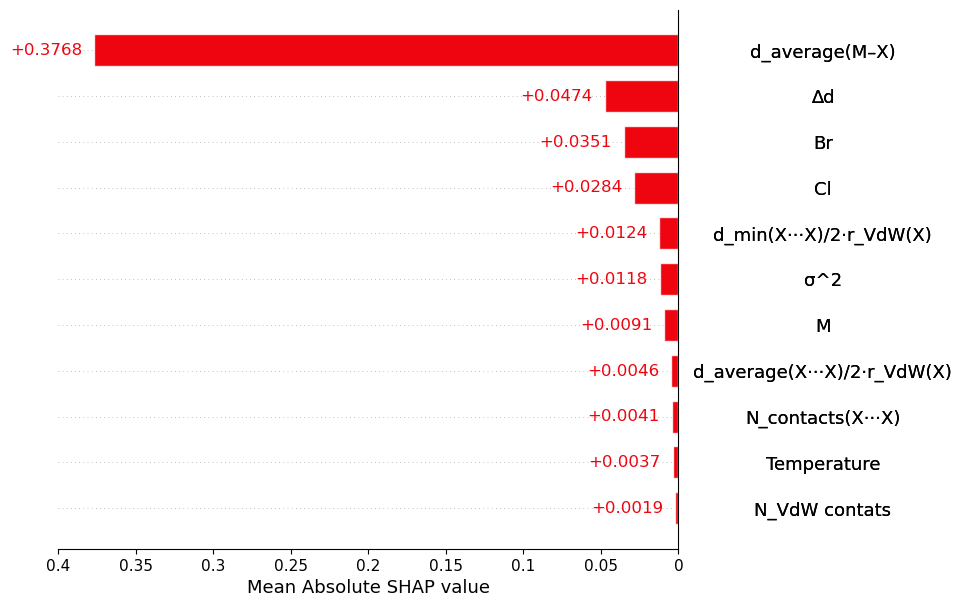

In [37]:
# Compute and visualization SHAP explanation
shap_vals2 = shap_explation(final_pipelines2, best_model_name2, X_train2)
shap_bar_plot(shap_values=shap_vals2, xlim_max=37, text_shift=5, decimal_places=4, change_colors=True)
plt.savefig(os.path.join(path_to_image, 'shap_bar_rdds.png'), dpi=720, bbox_inches='tight')

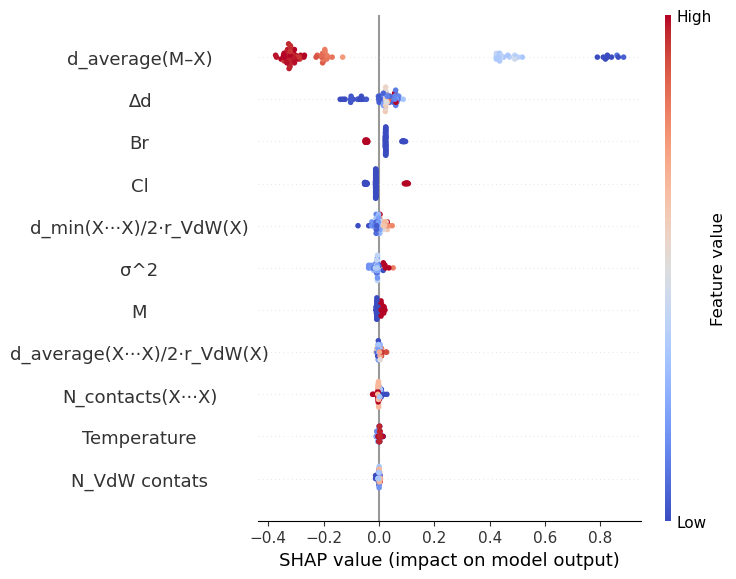

In [38]:
# Visualization SHAP explanations as beeswarm plot
shap.summary_plot(shap_vals2, X_train2,  show=False, cmap = 'coolwarm')

# Make centering of Y axis labels
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.225)

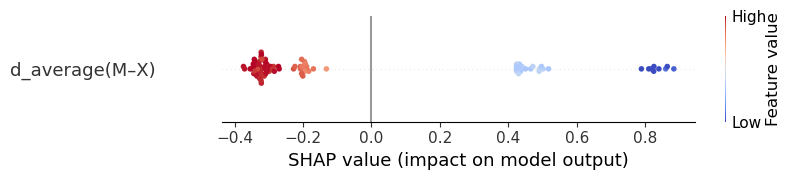

In [39]:
# For publication
shap.summary_plot(shap_vals2, X_train2, show=False, cmap = 'coolwarm', max_display=1)

# Make centering of Y axis labels
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.225)

plt.savefig(os.path.join(path_to_image, 'shap_beeswarm_rdds_1.png'), dpi=720, bbox_inches='tight')

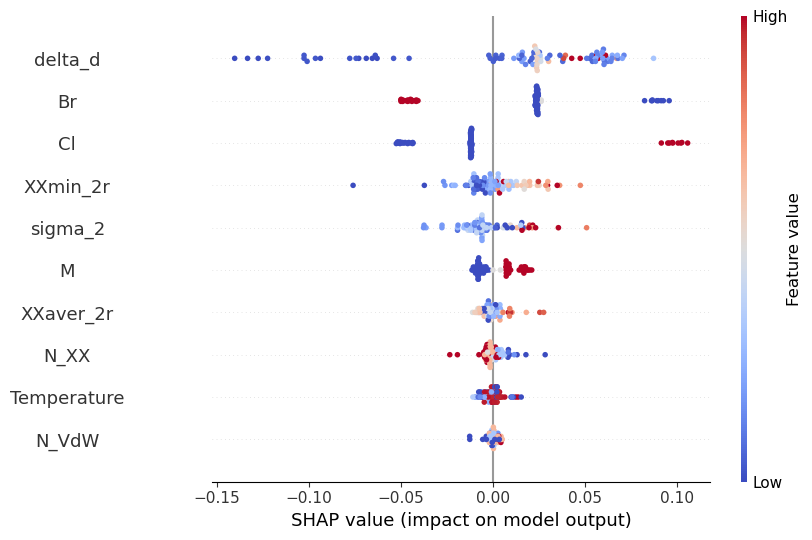

In [40]:
less_important_cols_ind2= [x for x in range(X_train2.shape[1]) if x not in pd.Series(np.abs(shap_vals2.values).mean(0)).sort_values()[-1:].index.to_list()]
shap.summary_plot(shap_vals2.values[:, less_important_cols_ind2], X_train2.iloc[:,less_important_cols_ind2], show=False, cmap = 'coolwarm')

# Make centering of Y axis labels
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.225)

plt.savefig(os.path.join(path_to_image, 'shap_beeswarm_rdds_2.png'), dpi=720, bbox_inches='tight')

***

## 3. Model-based optimization

In [41]:
# # Model-based optimization
history_df2, best_x2, best_Eg2 = model_based_optimization(pipline=final_pipelines2[best_model_name2],
                                                          feature_names=final_pipelines2[best_model_name2].named_steps['scaler'].feature_names_in_,
                                                          initial_guesses=[X_train2.loc[ind].to_dict() for ind in min_band_gap_values_inxs],
                                                          bounds_x=descriptor_bounds,
                                                          seed=seed,
                                                          n_trials=1000)

[I 2026-02-26 00:03:30,354] A new study created in memory with name: no-name-c510a6a8-4d09-4ad1-b5ce-9b05df8c5d35
[I 2026-02-26 00:03:30,398] Trial 0 finished with value: 1.7698185483870932 and parameters: {'Temperature': 293.0, 'd_average': 3.0963, 'delta_d': 0.0015441, 'sigma_2': 18.6921, 'N_XX': 6.0, 'N_VdW': 0.0, 'XXmin_2r': 1.047238095238095, 'XXaver_2r': 1.0883809523809524, 'M': 0.0, 'Br': 0.0, 'Cl': 0.0}. Best is trial 0 with value: 1.7698185483870932.
[I 2026-02-26 00:03:30,438] Trial 1 finished with value: 1.7581451612903305 and parameters: {'Temperature': 295.0, 'd_average': 3.0948, 'delta_d': 0.00156092, 'sigma_2': 22.8148, 'N_XX': 12.0, 'N_VdW': 0.0, 'XXmin_2r': 1.0240714285714283, 'XXaver_2r': 1.069595238095238, 'M': 0.0, 'Br': 0.0, 'Cl': 0.0}. Best is trial 1 with value: 1.7581451612903305.
[I 2026-02-26 00:03:30,480] Trial 2 finished with value: 2.003266129032259 and parameters: {'Temperature': 290.7630828937396, 'd_average': 3.0069472149560745, 'delta_d': 0.000876818462

In [42]:
# Convergence plot for model-based optimization process
fig_8 = optimization_convergence_plot(history_df=history_df2,
                                      layout_params=dict(xaxis=dict(tickformat='.0f',
                                                                    dtick=100)),
                                      )
fig_8.show()

In [43]:
# Minimal band gap found
pd.Series(best_x2)

Temperature    290.816904
d_average        3.111631
delta_d          0.001469
sigma_2         19.665231
N_XX            15.713457
N_VdW            0.314097
XXmin_2r         1.035656
XXaver_2r        1.081908
M                0.000000
Br               0.000000
Cl               0.000000
dtype: float64

In [44]:
best_Eg2

1.730302419354838

In [45]:
opimiziaion_results = pd.concat([pd.Series(best_x2),
                                 df.loc[min_band_gap_values_inxs][X_train2.columns].T,
                                 df[(df['M']==0)&(df['I']==1)][X_train2.columns].describe().T[['min', 'mean', 'max']]
                                 ],
                                 axis=1).round(7).iloc[:-3]
opimiziaion_results

,0,56,44,min,mean,max
Temperature,290.816904,293.000000,295.000000,93.000000,226.137255,330.000000
d_average,3.111631,3.096300,3.094800,3.026500,3.093727,3.135100
delta_d,0.001469,0.001544,0.001561,0.000962,0.002081,0.003189
sigma_2,19.665232,18.692100,22.814800,4.249900,18.176935,40.065800
N_XX,15.713457,6.000000,12.000000,0.500000,5.578431,12.000000
N_VdW,0.314097,0.000000,0.000000,0.000000,2.294118,7.000000
XXmin_2r,1.035656,1.047238,1.024071,0.871286,0.955211,1.105262
XXaver_2r,1.081908,1.088381,1.069595,0.934191,1.015281,1.105262


In [46]:
# Predicted band gap values%
pd.concat([pd.Series(predicted_values2['train'][best_model_name2], index=X_train2.index).loc[list(set(df[(df['M']==0)&(df['I']==1)].index) & set(X_train2.index))],
           pd.Series(predicted_values2['test'][best_model_name2], index=X_test.index).loc[list(set(df[(df['M']==0)&(df['I']==1)].index) & set(X_test.index))]]
           ).describe()

count    51.000000
mean      1.966724
std       0.095008
min       1.758145
25%       1.898095
50%       1.971290
75%       2.032107
max       2.180040
dtype: float64

***

## 3. Robustness verification

In [47]:
# Repeated hold-out validation
rhov_res1, rhov_res2 = repeated_hold_out_validation(df_raw=df, descritor_spaces=[X_train1.columns, X_train2.columns], hyperparameters_dicts=[best_trials1, best_trials2], split_seeds=range(105), seed=seed)

________________________________________
Split number 1
LOO-CV for Linear
RMSE on LOO-CV: 0.1114

Train final Linear

LOO-CV for GLR
RMSE on LOO-CV: 0.1101

Train final GLR

LOO-CV for ElasticNet
RMSE on LOO-CV: 0.1072

Train final ElasticNet

LOO-CV for SVR
RMSE on LOO-CV: 0.1166

Train final SVR

LOO-CV for GPR
RMSE on LOO-CV: 0.1084

Train final GPR

LOO-CV for RandomForest
RMSE on LOO-CV: 0.0972

Train final RandomForest

LOO-CV for ExtraTrees
RMSE on LOO-CV: 0.1025

Train final ExtraTrees

LOO-CV for XGBoost
RMSE on LOO-CV: 0.1216

Train final XGBoost

RMSE on test for Linear: 0.1326

RMSE on test for GLR: 0.1249

RMSE on test for ElasticNet: 0.1309

RMSE on test for SVR: 0.1325

RMSE on test for GPR: 0.1283

RMSE on test for RandomForest: 0.0974

RMSE on test for ExtraTrees: 0.089

RMSE on test for XGBoost: 0.1121

LOO-CV for Linear
RMSE on LOO-CV: 0.1131

Train final Linear

LOO-CV for GLR
RMSE on LOO-CV: 0.1147

Train final GLR

LOO-CV for ElasticNet
RMSE on LOO-CV: 0.1119

Tra

In [48]:
fig_9 = repeated_hold_out_validation_result_plot(rhov_result_df=rhov_res1, model_names=list(models_dict.keys()))
fig_9.show()

In [49]:
# Statisctic of repeated hold out validation
rhov_res_df1 = rhov_res1[rhov_res1.columns[1:]].groupby(['model', 'metric', 'offset']).describe()
rhov_res_df1

value                                          \
                                count      mean       std       min       25%   
model        metric offset                                                      
ElasticNet   MAE    test        105.0  0.087691  0.015720  0.049501  0.075552   
                    validation  105.0  0.087387  0.003885  0.077610  0.084343   
             R2     test        105.0  0.935229  0.016463  0.896036  0.925121   
                    validation  105.0  0.944852  0.003574  0.936976  0.941760   
             RMSE   test        105.0  0.111409  0.017342  0.070204  0.097938   
                    validation  105.0  0.112457  0.003991  0.101977  0.109798   
ExtraTrees   MAE    test        105.0  0.067470  0.017246  0.028992  0.055320   
                    validation  105.0  0.069629  0.003987  0.057064  0.066920   
             R2     test        105.0  0.953484  0.019523  0.906549  0.940624   
                    validation  105.0  0.958388  0.003573  0.951569  0.955926   
             RMSE   test        105.0  0.093154  0.023416  0.041306  0.076647   
                    validation  105.0  0.097647  0.004529  0.083252  0.094990   
GLR          MAE    test        105.0  0.085503  0.016150  0.053391  0.073269   
                    validation  105.0  0.087911  0.003607  0.078112  0.085322   
             R2     test        105.0  0.935167  0.018549  0.887078  0.924262   
                    validation  105.0  0.942151  0.003439  0.933346  0.939457   
             RMSE   test        105.0  0.111154  0.018182  0.066329  0.099919   
                    validation  105.0  0.115189  0.003822  0.106325  0.112513   
GPR          MAE    test        105.0  0.084866  0.017078  0.051623  0.072703   
                    validation  105.0  0.087076  0.003645  0.078936  0.084628   
             R2     test        105.0  0.934352  0.019763  0.881976  0.922666   
                    validation  105.0  0.942782  0.003432  0.935543  0.939996   
             RMSE   test        105.0  0.111774  0.019106  0.070583  0.097081   
                    validation  105.0  0.114557  0.003822  0.105953  0.111710   
Linear       MAE    test        105.0  0.085955  0.018221  0.052269  0.073069   
                    validation  105.0  0.089127  0.003719  0.080704  0.086464   
             R2     test        105.0  0.932836  0.022144  0.859965  0.919339   
                    validation  105.0  0.940786  0.003730  0.931022  0.938155   
             RMSE   test        105.0  0.112826  0.020346  0.069391  0.096778   
                    validation  105.0  0.116533  0.004018  0.108393  0.113493   
RandomForest MAE    test        105.0  0.072408  0.015059  0.045830  0.061260   
                    validation  105.0  0.075036  0.003927  0.063476  0.072447   
             R2     test        105.0  0.950882  0.018399  0.908246  0.938142   
                    validation  105.0  0.956586  0.003642  0.947263  0.954067   
             RMSE   test        105.0  0.096060  0.020411  0.058952  0.079735   
                    validation  105.0  0.099744  0.004478  0.088146  0.097030   
SVR          MAE    test        105.0  0.086161  0.018631  0.045841  0.072834   
                    validation  105.0  0.086814  0.007455  0.073228  0.082152   
             R2     test        105.0  0.932817  0.022876  0.871876  0.916316   
                    validation  105.0  0.941307  0.007794  0.916015  0.937706   
             RMSE   test        105.0  0.112761  0.021847  0.059709  0.098722   
                    validation  105.0  0.115839  0.007852  0.101782  0.109842   
XGBoost      MAE    test        105.0  0.084022  0.018173  0.041318  0.072920   
                    validation  105.0  0.090538  0.004054  0.081724  0.087947   
             R2     test        105.0  0.932985  0.027171  0.835191  0.915458   
                    validation  105.0  0.934434  0.005046  0.916567  0.931733   
             RMSE   test        105.0  0.112014  0.024251  0.05

In [50]:
fig_10 = repeated_hold_out_validation_result_plot(rhov_result_df=rhov_res2, model_names=list(models_dict.keys()))
fig_10.show()

In [51]:
# Statisctic of repeated hold out validation
rhov_res_df2 = rhov_res2[rhov_res2.columns[1:]].groupby(['model', 'metric', 'offset']).describe()
rhov_res_df2

value                                          \
                                count      mean       std       min       25%   
model        metric offset                                                      
ElasticNet   MAE    test        105.0  0.089464  0.016441  0.058432  0.076907   
                    validation  105.0  0.089018  0.003514  0.080854  0.087014   
             R2     test        105.0  0.928216  0.020412  0.871063  0.913800   
                    validation  105.0  0.940280  0.003282  0.933734  0.938014   
             RMSE   test        105.0  0.117079  0.019858  0.072919  0.102897   
                    validation  105.0  0.117044  0.003688  0.106780  0.114812   
ExtraTrees   MAE    test        105.0  0.072764  0.016362  0.040614  0.060943   
                    validation  105.0  0.073432  0.004143  0.063529  0.070505   
             R2     test        105.0  0.948962  0.020678  0.894578  0.933097   
                    validation  105.0  0.954606  0.004182  0.946100  0.951915   
             RMSE   test        105.0  0.097706  0.021949  0.051568  0.082136   
                    validation  105.0  0.101970  0.004931  0.089432  0.099369   
GLR          MAE    test        105.0  0.092427  0.016612  0.063484  0.080427   
                    validation  105.0  0.090807  0.003526  0.082519  0.088623   
             R2     test        105.0  0.924128  0.021585  0.858514  0.909502   
                    validation  105.0  0.937625  0.003560  0.930429  0.935105   
             RMSE   test        105.0  0.120346  0.020026  0.074190  0.106888   
                    validation  105.0  0.119613  0.003863  0.109686  0.117328   
GPR          MAE    test        105.0  0.089966  0.016229  0.058079  0.077538   
                    validation  105.0  0.089680  0.003523  0.081616  0.087844   
             R2     test        105.0  0.928225  0.020120  0.873515  0.914303   
                    validation  105.0  0.940029  0.003314  0.933500  0.937776   
             RMSE   test        105.0  0.117087  0.019619  0.073609  0.101664   
                    validation  105.0  0.117289  0.003712  0.106955  0.115127   
Linear       MAE    test        105.0  0.090667  0.016247  0.058042  0.079595   
                    validation  105.0  0.090704  0.003551  0.082443  0.088789   
             R2     test        105.0  0.927371  0.020128  0.875812  0.914064   
                    validation  105.0  0.938903  0.003393  0.932350  0.936584   
             RMSE   test        105.0  0.117794  0.019517  0.074332  0.102569   
                    validation  105.0  0.118385  0.003759  0.107974  0.116258   
RandomForest MAE    test        105.0  0.075335  0.017730  0.031805  0.062392   
                    validation  105.0  0.077959  0.004091  0.066313  0.075559   
             R2     test        105.0  0.944787  0.023729  0.857231  0.930382   
                    validation  105.0  0.951526  0.004374  0.943629  0.948067   
             RMSE   test        105.0  0.101476  0.024944  0.040627  0.082446   
                    validation  105.0  0.105384  0.005126  0.092001  0.102329   
SVR          MAE    test        105.0  0.086893  0.018163  0.051144  0.072454   
                    validation  105.0  0.085603  0.004126  0.075706  0.082499   
             R2     test        105.0  0.927903  0.022491  0.870652  0.911873   
                    validation  105.0  0.939929  0.005065  0.922517  0.936991   
             RMSE   test        105.0  0.117287  0.022595  0.068509  0.099942   
                    validation  105.0  0.117330  0.005212  0.104655  0.113688   
XGBoost      MAE    test        105.0  0.086279  0.017798  0.047730  0.073446   
                    validation  105.0  0.089339  0.005893  0.073389  0.086417   
             R2     test        105.0  0.931072  0.025905  0.850620  0.918522   
                    validation  105.0  0.936634  0.007521  0.908629  0.931804   
             RMSE   test        105.0  0.113870  0.023583  0.05

***

## 4. Save models

In [52]:
save_model_and_pipeline(final_pipelines1[best_model_name1], os.path.join(path_to_models, 'best_model_fgds'))
save_all_model_piplines(final_pipelines1,  os.path.join(path_to_models, 'all_models_fdgs'))
save_model_and_pipeline(final_pipelines2[best_model_name2], os.path.join(path_to_models, 'best_model_rdds'))
save_all_model_piplines(final_pipelines2,  os.path.join(path_to_models, 'all_models_rdds'))

***

## 5. Prepare figures and tables for publication

In [53]:
# Figure N in article
fig_11 = double_predicted_vs_actual_plot(y_train_pred_1=predicted_values1['train'][best_model_name1], y_train_pred_2=predicted_values2['train'][best_model_name2], y_train_true=y_train,
                                        y_test_pred_1=predicted_values1['test'][best_model_name1], y_test_pred_2=predicted_values2['test'][best_model_name2], y_test_true=y_test,
                                        train_text=df.loc[y_train.index, 'Refcode'], test_text=df.loc[y_test.index, 'Refcode'],
                                        results_1=results_df1.loc[best_model_name1], results_2=results_df2.loc[best_model_name2],
                                        subplot_titles=['Full Geometric Descriptor Space<br> ', 'Reduced Distortion Descriptor Space<br> '])

fig_11.show()

In [54]:
# Save figures:

# FGDS:
# fig_1.write_html(os.path.join(path_to_image, 'descriptors_heatmap_on_train_fgds.html'))
# fig_1.write_image(os.path.join(path_to_image, 'descriptors_heatmap_on_train_fgds.png'), scale=10)
# fig_2.write_html(os.path.join(path_to_image, 'best_model_predicted_vs_actual_fgds.html'))
# fig_2.write_image(os.path.join(path_to_image, 'best_model_predicted_vs_actual_fgds.png'), scale=10)
fig_3.write_html(os.path.join(path_to_image, 'all_models_predicted_vs_actual_fgds.html'))
fig_3.write_image(os.path.join(path_to_image, 'all_models_predicted_vs_actual_fgds.png'), scale=10)
fig_9.write_html(os.path.join(path_to_image, 'robustness_verification_fgds.html'))
fig_9.write_image(os.path.join(path_to_image, 'robustness_verification_fgds.png'), scale=10)

results_df1.to_excel(os.path.join(path_to_tables, 'fgds_results.xlsx'))
rhov_res_df1.to_excel(os.path.join(path_to_tables, 'robustness_verification_fgds.xlsx'))

# RDDS
# fig_5.write_html(os.path.join(path_to_image, 'descriptors_heatmap_on_train_rdds.html'))
# fig_5.write_image(os.path.join(path_to_image, 'descriptors_heatmap_on_train_rdds.png'), scale=10)
# fig_6.write_html(os.path.join(path_to_image, 'best_model_predicted_vs_actual_rdds.html'))
# fig_6.write_image(os.path.join(path_to_image, 'best_model_predicted_vs_actual_rdds.png'), scale=10)
fig_7.write_html(os.path.join(path_to_image, 'all_models_predicted_vs_actual_rdds.html'))
fig_7.write_image(os.path.join(path_to_image, 'all_models_predicted_vs_actual_rdds.png'), scale=10)
fig_10.write_html(os.path.join(path_to_image, 'robustness_verification_rdds.html'))
fig_10.write_image(os.path.join(path_to_image, 'robustness_verification_rdds.png'), scale=10)

results_df2.to_excel(os.path.join(path_to_tables, 'rdds_results.xlsx'))
rhov_res_df2.to_excel(os.path.join(path_to_tables, 'robustness_verification_rdds.xlsx'))

# Model-based optimization
fig_8.write_html(os.path.join(path_to_image, 'mbo_progress_rdds.html'))
fig_8.write_image(os.path.join(path_to_image, 'mbo_progress_rdds.png'), scale=10)
opimiziaion_results.to_excel(os.path.join(path_to_tables, 'mbo_rdds.xlsx'))
pd.Series(best_x2).to_excel(os.path.join(path_to_tables, 'mbo_best_found.xlsx'))

# Remaining
fig_11.write_html(os.path.join(path_to_image, 'predicted_vs_actual.html'))
fig_11.write_image(os.path.join(path_to_image, 'predicted_vs_actual.png'), scale=10)

***